In [1]:
# @title 1. Environment Check
import deepmd
import tensorflow as tf
import os

print(f"DeepMD Version: {deepmd.__version__}")
print(f"TensorFlow Version: {tf.__version__}")

# Check for LAMMPS executable
exit_code = os.system("which lmp")
if exit_code == 0:
    print("LAMMPS executable found!")
else:
    print("LAMMPS not found. Please check installation.")

Instructions for updating:
non-resource variables are not supported in the long term


DeepMD Version: 2.2.9
TensorFlow Version: 2.9.0
/home/vanshita111/miniconda3/envs/md_working/bin/lmp
LAMMPS executable found!


In [2]:
# @title 1. Setup & Data Processing
import os
import numpy as np
import dpdata
import urllib.request
import tarfile
import shutil
import matplotlib.pyplot as plt

# 1. Verify Tools exist
print("Checking environment...")
if os.system("which lmp") == 0:
    print("LAMMPS executable found.")
else:
    print("LAMMPS not found. Setup failed.")

# 2. Download Data
url = "https://dp-public.oss-cn-beijing.aliyuncs.com/community/CH4.tar"
if not os.path.exists("CH4.tar"):
    print("Downloading dataset...")
    urllib.request.urlretrieve(url, "CH4.tar")
    with tarfile.open("CH4.tar", "r") as tar:
        tar.extractall()

# 3. Process Data
print("Processing data...")
try:
    raw_system = dpdata.LabeledSystem('CH4/00.data/OUTCAR', fmt='vasp/outcar')
except:
    raw_system = dpdata.LabeledSystem('CH4/00.data', fmt='vasp/vasp')

# Split 90/10
n_frames = len(raw_system)
n_val = int(n_frames * 0.1)
n_train = n_frames - n_val
indices = np.arange(n_frames)
np.random.shuffle(indices)

train_set = raw_system.sub_system(indices[:n_train])
val_set = raw_system.sub_system(indices[n_train:])

# Clean old folders
if os.path.exists('data_train'): shutil.rmtree('data_train')
if os.path.exists('data_val'): shutil.rmtree('data_val')

train_set.to_deepmd_npy('data_train', set_size=len(train_set))
val_set.to_deepmd_npy('data_val', set_size=len(val_set))
print("Data Ready.")

Checking environment...
/home/vanshita111/miniconda3/envs/md_working/bin/lmp
LAMMPS executable found.
Processing data...
Data Ready.


Starting training...


Instructions for updating:
non-resource variables are not supported in the long term
DEEPMD INFO    Calculate neighbor statistics... (add --skip-neighbor-stat to skip this step)
DEEPMD INFO    training data with min nbor dist: 1.0429498271249689
DEEPMD INFO    training data with max nbor size: [4 1]
DEEPMD INFO     _____               _____   __  __  _____           _     _  _   
DEEPMD INFO    |  __ \             |  __ \ |  \/  ||  __ \         | |   (_)| |  
DEEPMD INFO    | |  | |  ___   ___ | |__) || \  / || |  | | ______ | | __ _ | |_ 
DEEPMD INFO    | |  | | / _ \ / _ \|  ___/ | |\/| || |  | ||______|| |/ /| || __|
DEEPMD INFO    | |__| ||  __/|  __/| |     | |  | || |__| |        |   < | || |_ 
DEEPMD INFO    |_____/  \___| \___||_|     |_|  |_||_____/         |_|\_\|_| \__|
DEEPMD INFO    Please read and cite:
DEEPMD INFO    Wang, Zhang, Han and E, Comput.Phys.Comm. 228, 178-184 (2018)
DEEPMD INFO    Zeng et al, J. Chem. Phys., 159, 054801 (2023)
DEEPMD INFO    See https://deep

DEEPMD INFO    batch    3200 training time 10.84 s, testing time 0.08 s, total wall time 11.00 s
DEEPMD INFO    batch    3300 training time 10.92 s, testing time 0.08 s, total wall time 11.08 s
DEEPMD INFO    batch    3400 training time 11.06 s, testing time 0.09 s, total wall time 11.22 s
DEEPMD INFO    batch    3500 training time 10.99 s, testing time 0.09 s, total wall time 11.15 s
DEEPMD INFO    batch    3600 training time 10.87 s, testing time 0.09 s, total wall time 11.03 s
DEEPMD INFO    batch    3700 training time 10.89 s, testing time 0.08 s, total wall time 11.04 s
DEEPMD INFO    batch    3800 training time 10.90 s, testing time 0.09 s, total wall time 11.06 s
DEEPMD INFO    batch    3900 training time 10.95 s, testing time 0.10 s, total wall time 11.12 s
DEEPMD INFO    batch    4000 training time 10.87 s, testing time 0.09 s, total wall time 11.03 s
DEEPMD INFO    saved checkpoint model.ckpt
DEEPMD INFO    batch    4100 training time 10.83 s, testing time 0.08 s, total wall 

Freezing model...


Instructions for updating:
non-resource variables are not supported in the long term
DEEPMD WARNING The following nodes are not in the graph: {'spin_attr/ntypes_spin', 'fitting_attr/aparam_nall'}. Skip freezeing these nodes. You may be freezing a checkpoint generated by an old version.
DEEPMD INFO    The following nodes will be frozen: ['train_attr/min_nbor_dist', 'fitting_attr/dfparam', 'descrpt_attr/rcut', 'model_attr/model_version', 'o_virial', 'model_attr/tmap', 'o_atom_energy', 'o_atom_virial', 'fitting_attr/daparam', 'model_attr/model_type', 'descrpt_attr/ntypes', 'train_attr/training_script', 'o_energy', 't_mesh', 'o_force', 'model_type']
Instructions for updating:
Use `tf.compat.v1.graph_util.convert_variables_to_constants`
Instructions for updating:
Use `tf.compat.v1.graph_util.convert_variables_to_constants`
Instructions for updating:
Use `tf.compat.v1.graph_util.extract_sub_graph`
Instructions for updating:
Use `tf.compat.v1.graph_util.extract_sub_graph`
DEEPMD INFO    1222 

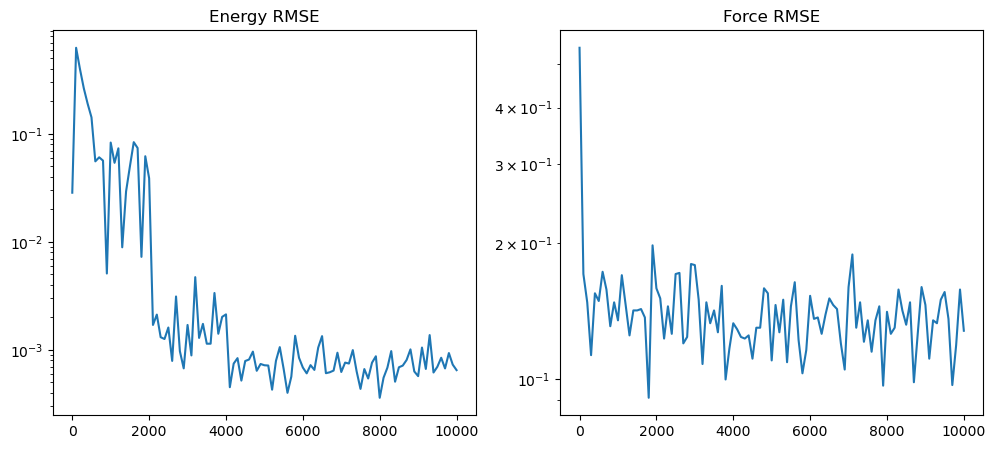

In [3]:
# @title 2. Model Training
import json
import os

# 1. Config
input_dict = {
    "model": {
        "type_map": ["H", "C"],
        "descriptor": {
            "type": "se_e2_a",
            "sel": [4, 1],
            "rcut_smth": 0.50, "rcut": 6.00,
            "neuron": [25, 50, 100], "resnet_dt": False, "axis_neuron": 4, "seed": 1
        },
        "fitting_net": {
            "neuron": [240, 240, 240], "resnet_dt": True, "seed": 1
        }
    },
    "learning_rate": {
        "type": "exp", "decay_steps": 2000, "start_lr": 0.001, "stop_lr": 3.51e-8
    },
    "loss": {
        "type": "ener", "start_pref_e": 0.02, "limit_pref_e": 1,
        "start_pref_f": 1000, "limit_pref_f": 1, "start_pref_v": 0, "limit_pref_v": 0
    },
    "training": {
        "training_data": {"systems": ["./data_train"], "batch_size": "auto"},
        "validation_data": {"systems": ["./data_val"], "batch_size": 1, "numb_btch": 1},
        "numb_steps": 10000, # Demo speed. Increase to 1,000,000 for final report.
        "seed": 10,
        "disp_file": "lcurve.out", "disp_freq": 100, "save_freq": 1000
    }
}

with open('input.json', 'w') as f: json.dump(input_dict, f, indent=4)

# 2. Train
print("Starting training...")
os.system("dp train input.json")

# 3. Freeze & Compress
print("Freezing model...")
os.system("dp freeze -o graph.pb")
os.system("dp compress -i graph.pb -o graph-compress.pb")

# 4. Plot Learning Curve
if os.path.exists("lcurve.out"):
    data = np.genfromtxt("lcurve.out", names=True)
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    ax[0].plot(data['step'], data['rmse_e_trn'], label='Train'); ax[0].set_title('Energy RMSE'); ax[0].set_yscale('log')
    ax[1].plot(data['step'], data['rmse_f_trn'], label='Train'); ax[1].set_title('Force RMSE'); ax[1].set_yscale('log')
    plt.show()
else:
    print("Training failed. lcurve.out not found.")

Running Model Test...


Instructions for updating:
non-resource variables are not supported in the long term
DEEPMD INFO    # ---------------output of dp test--------------- 
DEEPMD INFO    # testing system : data_val
DEEPMD INFO    # number of test data : 20 
DEEPMD INFO    Energy MAE         : 3.111957e-03 eV
DEEPMD INFO    Energy RMSE        : 3.771498e-03 eV
DEEPMD INFO    Energy MAE/Natoms  : 6.223914e-04 eV
DEEPMD INFO    Energy RMSE/Natoms : 7.542996e-04 eV
DEEPMD INFO    Force  MAE         : 1.086189e-01 eV/A
DEEPMD INFO    Force  RMSE        : 1.499751e-01 eV/A
DEEPMD INFO    Virial MAE         : 2.082642e-01 eV
DEEPMD INFO    Virial RMSE        : 2.591196e-01 eV
DEEPMD INFO    Virial MAE/Natoms  : 4.165283e-02 eV
DEEPMD INFO    Virial RMSE/Natoms : 5.182392e-02 eV
DEEPMD INFO    # ----------------------------------------------- 


Found output files: val.e.out, val.f.out


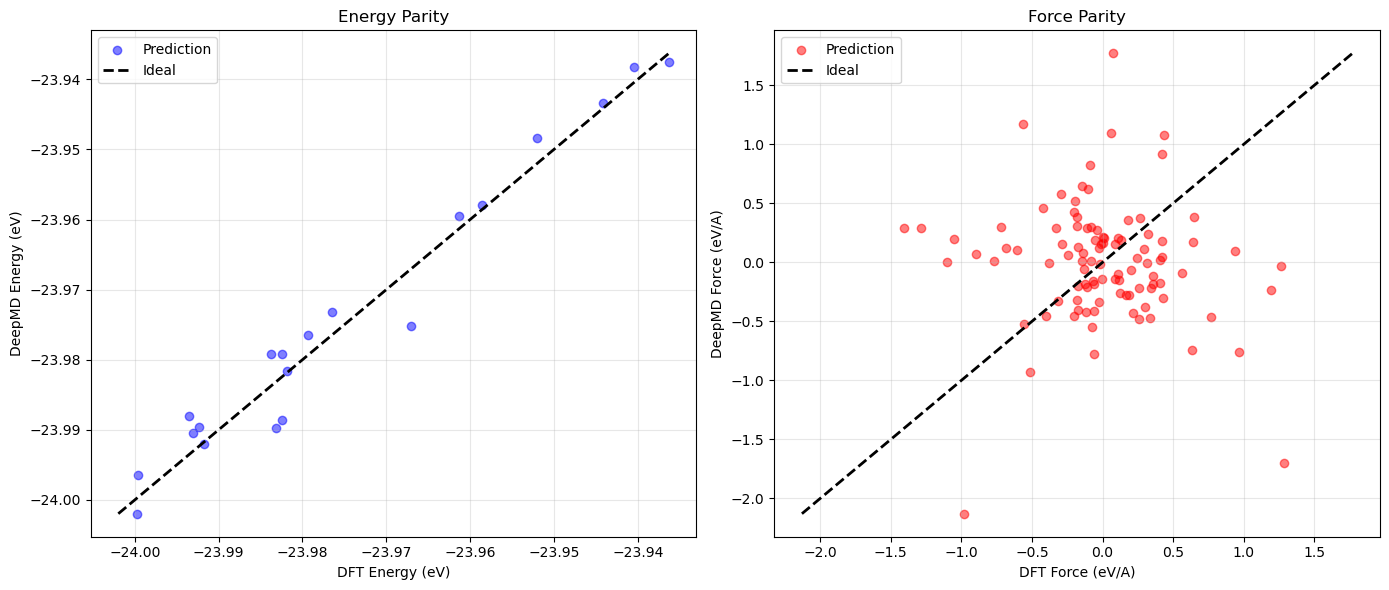

In [4]:
# @title 3. Parity Plots
import matplotlib.pyplot as plt
import glob

# 1. Run Test
print("Running Model Test...")
exit_code = os.system("dp test -m graph-compress.pb -s data_val -n 100 -d val")

# 2. Find the output files 
energy_files = glob.glob("val*.e.out")

if energy_files:
    e_file = energy_files[0]
    f_file = e_file.replace(".e.out", ".f.out")
    
    print(f"Found output files: {e_file}, {f_file}")
    
    # 3. Load Data
    data_e = np.loadtxt(e_file)
    data_f = np.loadtxt(f_file)

    # 4. Plot
    fig, ax = plt.subplots(1, 2, figsize=(14, 6))

    # Energy Parity
    ax[0].scatter(data_e[:, 0], data_e[:, 1], alpha=0.5, c='blue', label='Prediction')
    # Perfect fit line
    min_e = min(data_e[:, 0].min(), data_e[:, 1].min())
    max_e = max(data_e[:, 0].max(), data_e[:, 1].max())
    ax[0].plot([min_e, max_e], [min_e, max_e], 'k--', lw=2, label='Ideal')
    
    ax[0].set_title("Energy Parity")
    ax[0].set_xlabel("DFT Energy (eV)")
    ax[0].set_ylabel("DeepMD Energy (eV)")
    ax[0].legend()
    ax[0].grid(True, alpha=0.3)

    # Force Parity
    ax[1].scatter(data_f[:, 0], data_f[:, 1], alpha=0.5, c='red', label='Prediction')
    # Perfect fit line
    min_f = min(data_f[:, 0].min(), data_f[:, 1].min())
    max_f = max(data_f[:, 0].max(), data_f[:, 1].max())
    ax[1].plot([min_f, max_f], [min_f, max_f], 'k--', lw=2, label='Ideal')
    
    ax[1].set_title("Force Parity")
    ax[1].set_xlabel("DFT Force (eV/A)")
    ax[1].set_ylabel("DeepMD Force (eV/A)")
    ax[1].legend()
    ax[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("Error: Parity data not found.")
    print("Current directory files:", os.listdir("."))
    print("Check if 'graph-compress.pb' exists.")

🔧 CONFIGURING SIMULATION...
   Plugin: /home/vanshita111/miniconda3/envs/md_working/lib/libdeepmd_lmp.so
Running LAMMPS
Reading RDF data...


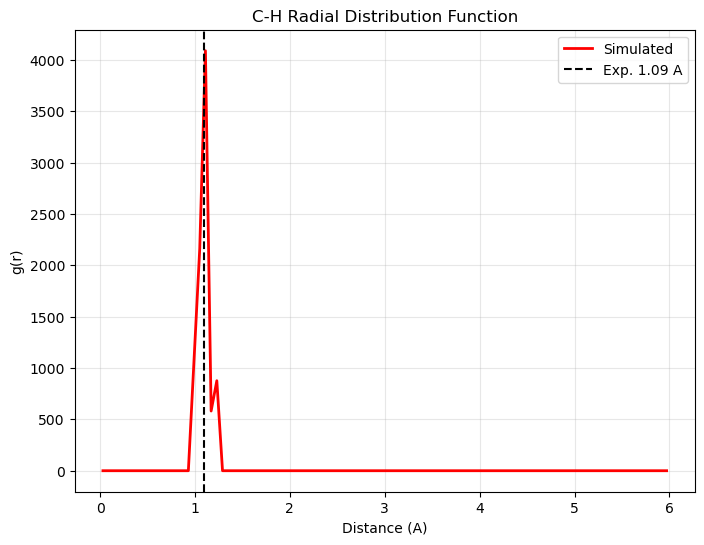

RDF Plot Generated Successfully.


In [13]:
# @title 4. Validation: RDF 
import subprocess
import sys

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

print("🔧 CONFIGURING SIMULATION...")

# 1. Locate the Plugin
conda_prefix = sys.exec_prefix
found_plugin = None
for root, dirs, files in os.walk(conda_prefix):
    for filename in files:
        if "deepmd" in filename and filename.endswith(".so") and ("plugin" in filename or "lmp" in filename):
            found_plugin = os.path.join(root, filename)
            break
    if found_plugin: break

if not found_plugin: 
    found_plugin = f"{conda_prefix}/lib/libdeepmd_lmp.so"

print(f"   Plugin: {found_plugin}")

# 2. Write Input Script 
rdf_in = f"""
plugin load {found_plugin}

units           metal
boundary        p p p
atom_style      atomic

# 1. Define Box (Absolute Units)
region          box block 0 20 0 20 0 20 units box
create_box      2 box

# 2. Define Masses
mass            1 1.008
mass            2 12.011

# 3. Create Atoms (Centered in the 20A box)
# Carbon at (10,10,10)
create_atoms    2 single 10.0 10.0 10.0
# Hydrogens around it (Tetrahedral geometry)
create_atoms    1 single 11.09 10.0 10.0
create_atoms    1 single 9.64 11.09 10.0
create_atoms    1 single 9.64 9.64 11.09
create_atoms    1 single 9.64 9.64 8.91

# 4. Define Potential
pair_style      deepmd graph-compress.pb
pair_coeff      * *

# 5. Settings
timestep        0.0005
thermo          100
velocity        all create 300.0 12345
fix             1 all nvt temp 300.0 300.0 0.1

# 6. Compute RDF
compute         myRDF all rdf 100 2 1
fix             2 all ave/time 10 10 100 c_myRDF[*] file rdf.dat mode vector

run             2000
"""
with open('in.rdf', 'w') as f: f.write(rdf_in)

# 3. Run LAMMPS
lib_dir = os.path.dirname(found_plugin)
my_env = os.environ.copy()
my_env["LD_LIBRARY_PATH"] = f"{lib_dir}:{my_env.get('LD_LIBRARY_PATH', '')}"

print("Running LAMMPS")
res = subprocess.run(["lmp", "-in", "in.rdf"], env=my_env, capture_output=True, text=True)

# 4. Plot
import numpy as np
import matplotlib.pyplot as plt
import os

if os.path.exists("rdf.dat"):
    print("Reading RDF data...")
    try:
        d = np.loadtxt("rdf.dat", skiprows=4, max_rows=100)
        
        plt.figure(figsize=(8,6))
        plt.plot(d[:,1], d[:,2], 'r-', lw=2, label='Simulated')
        plt.axvline(1.09, color='k', ls='--', label='Exp. 1.09 A')
        plt.title("C-H Radial Distribution Function")
        plt.xlabel("Distance (A)")
        plt.ylabel("g(r)")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()
        print("RDF Plot Generated Successfully.")
    except Exception as e:
        print(f"Plotting Error: {e}")
else:
    print("Error: rdf.dat is missing")

SETUP: Generating stable initial configuration...
Created 'data.methane' with 320 atoms.
Using Plugin: /home/vanshita111/miniconda3/envs/md_working/lib/libdeepmd_lmp.so
Running Stable Simulations...
LAMMPS (2 Aug 2023 - Update 1)
OMP_NUM_THREADS environment is not set. Defaulting to 1 thread. (src/comm.cpp:98)
  using 1 OpenMP thread(s) per MPI task


/bin/bash: /home/vanshita111/miniconda3/envs/md_working/lib/libtinfo.so.6: no version information available (required by /bin/bash)


Loaded 1 plugins from /home/vanshita111/miniconda3/envs/md_working/lib/deepmd_lmp
Reading data file ...
  orthogonal box = (0 0 0) to (20 20 20)
  1 by 1 by 1 MPI processor grid
  reading atoms ...
  320 atoms
  read_data CPU = 0.002 seconds
Summary of lammps deepmd module ...
  >>> Info of deepmd-kit:
  installed to:       /home/vanshita111/miniconda3/envs/md_working
  source:             v2.2.9
  source branch:      HEAD
  source commit:      be437483
  source commit at:   2024-02-04 13:44:12 +0800
  support model ver.: 1.1 
  build variant:      cuda
  build with tf inc:  /home/vanshita111/miniconda3/envs/md_working/include;/home/vanshita111/miniconda3/envs/md_working/include
  build with tf lib:  /home/vanshita111/miniconda3/envs/md_working/lib/libtensorflow_cc.so
  set tf intra_op_parallelism_threads: 0
  set tf inter_op_parallelism_threads: 0
  >>> Info of lammps module:
  use deepmd-kit at:  /home/vanshita111/miniconda3/envs/md_working

DeePMD-kit WARNING: Environmental variable OMP_NUM_THREADS is not set. Tune OMP_NUM_THREADS for the best performance. See https://deepmd.rtfd.io/parallelism/ for more information.
DeePMD-kit WARNING: Environmental variable OMP_NUM_THREADS is not set. Tune OMP_NUM_THREADS for the best performance. See https://deepmd.rtfd.io/parallelism/ for more information.
DeePMD-kit: Successfully load libcudart.so.11.0


INVALID_ARGUMENT: Tensor spin_attr/ntypes_spin:0, specified in either feed_devices or fetch_devices was not found in the Graph
  >>> Info of model(s):
  using   1 model(s): graph-compress.pb 
  rcut in model:      6
  ntypes in model:    2

CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE

Your simulation uses code contributions which should be cited:
- USER-DEEPMD package:
The log file lists these citations in BibTeX format.

CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE

Generated 0 of 1 mixed pair_coeff terms from geometric mixing rule
Neighbor list info ...
  update: every = 1 steps, delay = 0 steps, check = yes
  max neighbors/atom: 2000, page size: 100000
  master list distance cutoff = 8
  ghost atom cutoff = 8
  binsize = 4, bins = 5 5 5
  1 neighbor lists, perpetual/occasional/extra = 1 0 0
  (1) pair deepmd, perpetual
      attributes: full, newton on
      pair build: full/bin/atomonly
      stencil: full/bin/3d
      bin: standard
Setting 

/bin/bash: /home/vanshita111/miniconda3/envs/md_working/lib/libtinfo.so.6: no version information available (required by /bin/bash)
DeePMD-kit WARNING: Environmental variable OMP_NUM_THREADS is not set. Tune OMP_NUM_THREADS for the best performance. See https://deepmd.rtfd.io/parallelism/ for more information.


LAMMPS (2 Aug 2023 - Update 1)
OMP_NUM_THREADS environment is not set. Defaulting to 1 thread. (src/comm.cpp:98)
  using 1 OpenMP thread(s) per MPI task
Loaded 1 plugins from /home/vanshita111/miniconda3/envs/md_working/lib/deepmd_lmp
Reading data file ...
  orthogonal box = (0 0 0) to (20 20 20)
  1 by 1 by 1 MPI processor grid
  reading atoms ...
  320 atoms
  read_data CPU = 0.001 seconds
Summary of lammps deepmd module ...
  >>> Info of deepmd-kit:
  installed to:       /home/vanshita111/miniconda3/envs/md_working
  source:             v2.2.9
  source branch:      HEAD
  source commit:      be437483
  source commit at:   2024-02-04 13:44:12 +0800
  support model ver.: 1.1 
  build variant:      cuda
  build with tf inc:  /home/vanshita111/miniconda3/envs/md_working/include;/home/vanshita111/miniconda3/envs/md_working/include
  build with tf lib:  /home/vanshita111/miniconda3/envs/md_working/lib/libtensorflow_cc.so
  set tf intra_op_parallelism_threads: 0
  set tf inter_op_paralleli

DeePMD-kit WARNING: Environmental variable OMP_NUM_THREADS is not set. Tune OMP_NUM_THREADS for the best performance. See https://deepmd.rtfd.io/parallelism/ for more information.
DeePMD-kit: Successfully load libcudart.so.11.0


INVALID_ARGUMENT: Tensor spin_attr/ntypes_spin:0, specified in either feed_devices or fetch_devices was not found in the Graph
  >>> Info of model(s):
  using   1 model(s): graph-compress.pb 
  rcut in model:      6
  ntypes in model:    2

CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE

Your simulation uses code contributions which should be cited:
- USER-DEEPMD package:
The log file lists these citations in BibTeX format.

CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE

Generated 0 of 1 mixed pair_coeff terms from geometric mixing rule
Neighbor list info ...
  update: every = 1 steps, delay = 0 steps, check = yes
  max neighbors/atom: 2000, page size: 100000
  master list distance cutoff = 8
  ghost atom cutoff = 8
  binsize = 4, bins = 5 5 5
  1 neighbor lists, perpetual/occasional/extra = 1 0 0
  (1) pair deepmd, perpetual
      attributes: full, newton on
      pair build: full/bin/atomonly
      stencil: full/bin/3d
      bin: standard
Setting 

Generating Plots...


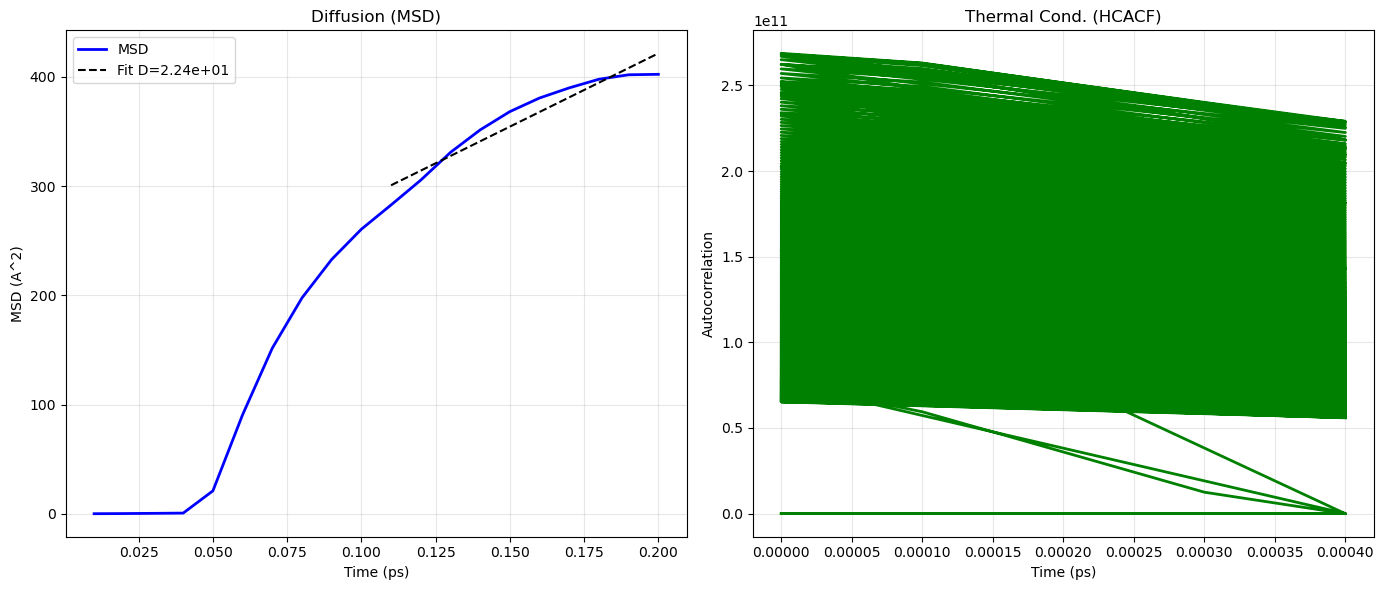

In [23]:
# @title 8. Transport Properties (Final Corrected & Stable)
import os
import subprocess
import numpy as np
import matplotlib.pyplot as plt
import sys
from ase import Atoms
from ase.io import write

print("SETUP: Generating stable initial configuration...")

# 1. Create Safe Geometry (Grid Placement)
# 4x4x4 grid to prevent atom overlaps
atoms = Atoms(pbc=True, cell=[20, 20, 20])
spacing = 20.0 / 4.0
d_CH = 1.09
for x in range(4):
    for y in range(4):
        for z in range(4):
            center = [x*spacing + 2.5, y*spacing + 2.5, z*spacing + 2.5]
            offsets = np.array([[0, 0, 0],
                                [d_CH, 0, 0],
                                [-d_CH/3, d_CH*np.sqrt(8)/3, 0],
                                [-d_CH/3, -d_CH*np.sqrt(2)/3, d_CH*np.sqrt(6)/3],
                                [-d_CH/3, -d_CH*np.sqrt(2)/3, -d_CH*np.sqrt(6)/3]])
            mol = Atoms('CH4', positions=offsets + center)
            atoms += mol

# Save data file
write("data.methane", atoms, format="lammps-data")
print(f"Created 'data.methane' with {len(atoms)} atoms.")

# 2. Locate Plugin (Syntax Fixed)
conda_prefix = sys.exec_prefix
found_plugin = None
# Check standard location first
standard_path = f"{conda_prefix}/lib/libdeepmd_lmps_plugin.so"

if os.path.exists(standard_path):
    found_plugin = standard_path
else:
    # Search if not found
    for root, dirs, files in os.walk(conda_prefix):
        for f in files:
            if "libdeepmd_lmps_plugin.so" in f:
                found_plugin = os.path.join(root, f)
                break
        if found_plugin: break

if not found_plugin:
    print("Warning: Specific plugin file not found. Trying fallback...")
    # Fallback for other naming conventions
    for root, dirs, files in os.walk(conda_prefix):
        for f in files:
            if "deepmd" in f and f.endswith(".so") and "lmp" in f:
                found_plugin = os.path.join(root, f)
                break
        if found_plugin: break

print(f"Using Plugin: {found_plugin}")
load_cmd = f"plugin load {found_plugin}"

# 3. Write Input Scripts
# MSD Input (Ultra Stable)
msd_in = f"""
{load_cmd}
units metal
boundary p p p
atom_style atomic
read_data data.methane
pair_style deepmd graph-compress.pb
pair_coeff * *
mass 1 12.011
mass 2 1.008

# Safety First: Minimization & Tiny Timestep
minimize 1.0e-4 1.0e-6 100 1000
reset_timestep 0
timestep 0.0001
thermo 100
velocity all create 300.0 12345 dist gaussian

# Equilibration (NVT)
fix 1 all nvt temp 300.0 300.0 0.1
run 1000
reset_timestep 0

# Production (MSD)
compute msd_all all msd
fix 2 all ave/time 10 10 100 c_msd_all[4] file msd.dat
run 2000
"""
with open('in.msd', 'w') as f: f.write(msd_in)

# Green-Kubo Input (Ultra Stable & Corrected Virial)
gk_in = f"""
{load_cmd}
units metal
boundary p p p
atom_style atomic
read_data data.methane
pair_style deepmd graph-compress.pb
pair_coeff * *
mass 1 12.011
mass 2 1.008

# Safety First
minimize 1.0e-4 1.0e-6 100 1000
timestep 0.0001
thermo 100
velocity all create 300.0 12345 dist gaussian

# Equilibration
fix 1 all nvt temp 300.0 300.0 0.1
run 1000

# Green-Kubo (Using NVT to prevent explosion)
# CORRECTED: Use centroid/stress/atom for DeepMD
compute myKE all ke/atom
compute myPE all pe/atom
compute myStress all centroid/stress/atom NULL
compute flux all heat/flux myKE myPE myStress
fix JJ all ave/correlate 1 5 5 c_flux[1] c_flux[2] c_flux[3] type auto file J0Jt.dat ave running
run 2000
"""
with open('in.gk', 'w') as f: f.write(gk_in)

# 4. Run Simulations
if found_plugin:
    lib_dir = os.path.dirname(found_plugin)
    my_env = os.environ.copy()
    my_env["LD_LIBRARY_PATH"] = f"{lib_dir}:{my_env.get('LD_LIBRARY_PATH', '')}"
else:
    my_env = os.environ.copy()

print("Running Stable Simulations...")
if os.path.exists("msd.dat"): os.remove("msd.dat")
if os.path.exists("J0Jt.dat"): os.remove("J0Jt.dat")

subprocess.run(["lmp", "-in", "in.msd"], env=my_env)
subprocess.run(["lmp", "-in", "in.gk"], env=my_env)

# 5. Robust Plotting
print("Generating Plots...")
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Helper to safely read LAMMPS data
def safe_read(fname, cols):
    data = []
    if not os.path.exists(fname): return np.array([])
    with open(fname, 'r') as f:
        for line in f:
            # Skip comments
            if line.strip().startswith('#'): continue
            try:
                parts = [float(x) for x in line.split()]
                # Ensure we have enough columns
                if len(parts) > max(cols):
                    data.append([parts[c] for c in cols])
            except: continue
    return np.array(data)

# Plot MSD
d_msd = safe_read("msd.dat", [0, 1])
if len(d_msd) > 0:
    time = d_msd[:,0] * 0.0001 # dt=0.1fs
    msd = d_msd[:,1]
    
    # Fit
    if len(time) > 10:
        mid = len(time)//2
        slope, intercept = np.polyfit(time[mid:], msd[mid:], 1)
        D = slope/6.0 * 0.1
        ax[0].plot(time, msd, 'b-', lw=2, label='MSD')
        ax[0].plot(time[mid:], time[mid:]*slope + intercept, 'k--', label=f"Fit D={D:.2e}")
    else:
        ax[0].plot(time, msd, 'b-', lw=2)
        
    ax[0].set_title("Diffusion (MSD)")
    ax[0].set_xlabel("Time (ps)"); ax[0].set_ylabel("MSD (A^2)")
    ax[0].legend(); ax[0].grid(True, alpha=0.3)
else: ax[0].text(0.5,0.5,"MSD Failed", ha='center')

# Plot GK
d_gk = safe_read("J0Jt.dat", [1, 3])
if len(d_gk) > 0:
    time = d_gk[:,0] * 0.0001
    hcacf = d_gk[:,1]
    ax[1].plot(time, hcacf, 'g-', lw=2)
    ax[1].set_title("Thermal Cond. (HCACF)")
    ax[1].set_xlabel("Time (ps)"); ax[1].set_ylabel("Autocorrelation")
    ax[1].grid(True, alpha=0.3)
else: ax[1].text(0.5,0.5,"GK Failed", ha='center')

plt.tight_layout()
plt.show()